# 02 - Modelling : XGBoost et strategies de resampling

Objectif : comparer plusieurs strategies de modelisation sur le dataset IEEE-CIS Fraud Detection avec des metriques adaptees a la fraude.

Ce notebook repond a la question metier : **le modele fait-il mieux qu'une baseline naive, et quelle strategie recommander au CDO ?**

On compare :
- XGBoost brut ;
- XGBoost avec `scale_pos_weight` ;
- Random Undersampling ;
- SMOTE ;
- SMOTEENN.

Points importants :
- le split est temporel ;
- le preprocessor est ajuste uniquement sur le train ;
- les strategies de resampling sont appliquees uniquement sur le train transforme ;
- les metriques principales sont AUPRC, recall fraude, F1 et temps d'entrainement.


## 0. Installation et imports

Si une dependance manque :

```bash
pip install polars pyarrow pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn
```

Remarque : SMOTE et SMOTEENN peuvent etre couteux sur un dataset large. Une variable `MAX_TRAIN_ROWS_FOR_RESAMPLING` permet de limiter le train pour les strategies les plus lentes si necessaire.


In [1]:
from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


## 1. Configuration du notebook

Par defaut, le notebook utilise toutes les lignes du dataset. Si SMOTE ou SMOTEENN prennent trop de temps, reduis `MAX_TRAIN_ROWS_FOR_RESAMPLING` a `150_000` ou `100_000`.

Cette limite ne sert qu'a rendre l'experimentation possible sur une machine locale. Dans le rendu, indique clairement si tu as limite le volume.


In [2]:
VALID_SIZE = 0.20

# Mode compact par defaut pour eviter les crashes memoire en local.
# "compact" exclut les centaines de colonnes Vxxx ; "wide" les garde si ta machine a assez de RAM.
FEATURE_SET = "compact"

# Limite uniquement pour les strategies couteuses comme SMOTE/SMOTEENN.
# None = tout utiliser, mais cela peut etre tres lent et consommer beaucoup de RAM.
MAX_TRAIN_ROWS_FOR_RESAMPLING = 150_000

DECISION_THRESHOLD = 0.5

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement et enrichissement minimal

On charge les donnees avec Polars, on fusionne transaction + identity, puis on cree quelques variables temporelles simples.

Le dataset est trie par `TransactionDT` avant le split pour simuler la production : entrainement sur le passe, validation sur le futur.


In [3]:
start = time.time()

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

print(f"Dataset charge : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")
train.select(["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD", "day_rel"]).head()


Dataset charge : (590540, 438)
Temps : 93.0 secondes


TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,day_rel
i64,i64,i64,f64,str,i64
2987000,0,86400,68.5,"""W""",1
2987001,0,86401,29.0,"""W""",1
2987002,0,86469,59.0,"""W""",1
2987003,0,86499,50.0,"""W""",1
2987004,0,86506,50.0,"""H""",1


## 3. Feature engineering temporel sans fuite

On ajoute des features historiques simples et des vraies fenetres temporelles demandees dans le sujet :

- nombre de transactions precedentes pour le proxy client ;
- moyenne historique precedente du montant ;
- ratio montant / moyenne historique ;
- nouveau marchand ;
- nombre de transactions du meme client dans les **1h**, **24h** et **7 jours** precedents ;
- montant cumule du meme client dans les **1h**, **24h** et **7 jours** precedents.

IEEE-CIS ne fournit pas de vrai identifiant client. On utilise donc un `customer_proxy` base sur des variables carte/adresse. C'est une approximation a documenter dans le rapport.

Les fenetres sont calculees sans fuite de donnees : pour une transaction au temps `t`, on utilise uniquement les transactions du meme proxy client strictement anterieures a `t`.


In [4]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

# Les fenetres sont exprimees en secondes car TransactionDT est un temps relatif en secondes.
WINDOW_SPECS = {
    "1h": 60 * 60,
    "24h": 24 * 60 * 60,
    "7d": 7 * 24 * 60 * 60,
}

# Rend la cellule relancable : si les features existent deja, on les supprime avant de les recalculer.
base_generated_cols = [
    "txn_row_id", "customer_proxy", "merchant_proxy",
    "customer_tx_count_prev", "customer_amt_sum_prev", "customer_amt_mean_prev",
    "amt_to_customer_mean_prev", "merchant_seen_count_prev", "is_new_merchant_for_customer",
]
window_generated_cols = []
for label in WINDOW_SPECS:
    window_generated_cols.extend([
        f"customer_tx_count_before_{label}",
        f"customer_amt_sum_before_{label}",
        f"customer_tx_count_prev_{label}",
        f"customer_amt_sum_prev_{label}",
    ])
cols_to_reset = [col for col in base_generated_cols + window_generated_cols if col in train.columns]
if cols_to_reset:
    train = train.drop(cols_to_reset)

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        # Cumul incluant la transaction courante. On soustrait ensuite la transaction courante
        # pour obtenir uniquement l'historique precedent.
        pl.cum_count("TransactionID").over("customer_proxy").alias("customer_tx_count_cum"),
        pl.col("TransactionAmt").cum_sum().over("customer_proxy").alias("customer_amt_cumsum"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.col("customer_tx_count_cum").sub(1).alias("customer_tx_count_prev"),
        (pl.col("customer_amt_cumsum") - pl.col("TransactionAmt")).alias("customer_amt_sum_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev"))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
    ])
)

# Table historique pour retrouver, par client, le cumul disponible juste avant le debut de chaque fenetre.
# Exemple pour 24h : window_count = cumul avant t - cumul avant ou a t-24h.
history_lookup = train.select([
    "customer_proxy",
    "TransactionDT",
    "customer_tx_count_cum",
    "customer_amt_cumsum",
]).sort("TransactionDT")

helper_cols_to_drop = ["customer_tx_count_cum", "customer_amt_cumsum"]
window_features = []

for label, seconds in WINDOW_SPECS.items():
    before_count_col = f"customer_tx_count_before_{label}"
    before_sum_col = f"customer_amt_sum_before_{label}"
    count_col = f"customer_tx_count_prev_{label}"
    sum_col = f"customer_amt_sum_prev_{label}"

    cutoff_points = (
        train
        .select([
            "txn_row_id",
            "customer_proxy",
            (pl.col("TransactionDT") - seconds).alias("window_start_dt"),
        ])
        .sort("window_start_dt")
    )

    window_start_history = (
        cutoff_points
        .join_asof(
            history_lookup,
            left_on="window_start_dt",
            right_on="TransactionDT",
            by="customer_proxy",
            strategy="backward",
        )
        .select([
            "txn_row_id",
            pl.col("customer_tx_count_cum").fill_null(0).alias(before_count_col),
            pl.col("customer_amt_cumsum").fill_null(0.0).alias(before_sum_col),
        ])
    )

    train = (
        train
        .join(window_start_history, on="txn_row_id", how="left")
        .with_columns([
            pl.max_horizontal([
                pl.col("customer_tx_count_prev") - pl.col(before_count_col),
                pl.lit(0),
            ]).alias(count_col),
            pl.max_horizontal([
                pl.col("customer_amt_sum_prev") - pl.col(before_sum_col),
                pl.lit(0.0),
            ]).alias(sum_col),
        ])
    )

    window_features.extend([count_col, sum_col])
    helper_cols_to_drop.extend([before_count_col, before_sum_col])

engineered_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
] + window_features

train = (
    train
    .drop(helper_cols_to_drop)
    .sort("txn_row_id")
)

print("Features temporelles ajoutees :")
print(engineered_features)

train.select(engineered_features + ["isFraud"]).filter(pl.col("customer_tx_count_prev") > 0).head(10)


Features temporelles ajoutees :
['customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


customer_tx_count_prev,customer_amt_mean_prev,amt_to_customer_mean_prev,is_new_merchant_for_customer,customer_tx_count_prev_1h,customer_amt_sum_prev_1h,customer_tx_count_prev_24h,customer_amt_sum_prev_24h,customer_tx_count_prev_7d,customer_amt_sum_prev_7d,isFraud
u32,f64,f64,i8,u32,f64,u32,f64,u32,f64,i64
1,200.0,1.13,0,1,200.0,1,200.0,1,200.0,0
1,49.0,1.203061,0,1,49.0,1,49.0,1,49.0,0
1,40.0,0.5,1,1,40.0,1,40.0,1,40.0,0
1,500.0,1.108,0,1,500.0,1,500.0,1,500.0,0
1,42.294,0.657138,1,1,42.294,1,42.294,1,42.294,0
1,77.0,0.88961,0,1,77.0,1,77.0,1,77.0,0
1,250.0,1.12,0,1,250.0,1,250.0,1,250.0,0
1,114.95,0.913006,0,1,114.95,1,114.95,1,114.95,0
2,35.0435,1.215518,1,2,70.087,2,70.087,2,70.087,0


## 4. Selection des features

Pour garder un notebook robuste et raisonnablement rapide, on utilise :
- les variables numeriques avec moins de 80 % de valeurs manquantes ;
- quelques variables categorielles lisibles et utiles ;
- les features temporelles construites ci-dessus.

On exclut `TransactionID`, `TransactionDT`, la cible et les proxys texte crees pour le feature engineering.


In [5]:
numeric_dtypes = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}

exclude_cols = {
    "TransactionID", "TransactionDT", "isFraud",
    "customer_proxy", "merchant_proxy",
    # Colonnes techniques creees pour le calcul des features temporelles.
    "txn_row_id", "merchant_seen_count_prev", "customer_amt_sum_prev",
}

# Set compact : suffisamment riche pour une comparaison XGBoost/resampling,
# mais beaucoup plus leger que les centaines de colonnes Vxxx.
compact_numeric_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
]

if FEATURE_SET == "wide":
    numeric_cols = [
        name for name, dtype in train.schema.items()
        if dtype in numeric_dtypes and name not in exclude_cols
    ]
    nonnull_rates = train.select([
        pl.col(col).is_not_null().mean().alias(col) for col in numeric_cols
    ]).to_dicts()[0]
    numeric_features = [col for col in numeric_cols if nonnull_rates[col] >= 0.20]
else:
    numeric_features = [col for col in compact_numeric_candidates if col in train.columns]

candidate_categorical_features = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]
categorical_features = [col for col in candidate_categorical_features if col in train.columns]

feature_cols = list(dict.fromkeys(numeric_features + categorical_features + engineered_features))

print(f"FEATURE_SET : {FEATURE_SET}")
print(f"Features numeriques : {len(numeric_features)}")
print(f"Features categorielles : {len(categorical_features)}")
print(f"Features totales : {len(feature_cols)}")
print(feature_cols)


FEATURE_SET : compact
Features numeriques : 34
Features categorielles : 15
Features totales : 59
['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D15', 'hour_rel', 'day_rel', 'week_rel', 'hour_of_day_rel', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


## 5. Split temporel train / validation

Le split est fait apres tri par `TransactionDT`. La validation represente le futur. C'est indispensable pour eviter un score artificiellement optimiste.


In [6]:
# On deduplique car day_rel peut deja etre present dans feature_cols.
model_columns = list(dict.fromkeys(feature_cols + ["isFraud", "day_rel"]))

# On evite de convertir tout le dataset en pandas d'un coup : c'est souvent la cause du crash kernel.
split_idx = int(train.height * (1 - VALID_SIZE))
train_pd = train.slice(0, split_idx).select(model_columns).to_pandas()
valid_pd = train.slice(split_idx, train.height - split_idx).select(model_columns).to_pandas()

X_train = train_pd[feature_cols]
y_train = train_pd["isFraud"].astype(int)
X_valid = valid_pd[feature_cols]
y_valid = valid_pd["isFraud"].astype(int)

print(f"Train : {X_train.shape}, jours {train_pd['day_rel'].min()} -> {train_pd['day_rel'].max()}")
print(f"Valid : {X_valid.shape}, jours {valid_pd['day_rel'].min()} -> {valid_pd['day_rel'].max()}")
print(f"Taux fraude train : {y_train.mean():.4%}")
print(f"Taux fraude valid : {y_valid.mean():.4%}")

# A partir d'ici, on travaille en pandas/numpy pour sklearn/xgboost.
del train
gc.collect()


Train : (472432, 59), jours 1 -> 141
Valid : (118108, 59), jours 141 -> 182
Taux fraude train : 3.5135%
Taux fraude valid : 3.4409%


0

## 6. Preprocessing ajuste uniquement sur le train

On encode les categories avec `OrdinalEncoder`. Pour XGBoost, c'est souvent suffisant comme baseline. On n'utilise pas `OneHotEncoder` ici pour eviter une matrice trop large avec SMOTE.

Important : le preprocessor est `fit` sur le train seulement, puis applique a la validation. Cela evite une fuite de donnees.


In [7]:
numeric_features_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = [col for col in feature_cols if col not in numeric_features_final]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_final),
        ("cat", categorical_pipeline, categorical_features_final),
    ],
    remainder="drop",
)

start = time.time()
X_train_prepared = preprocess.fit_transform(X_train)
X_valid_prepared = preprocess.transform(X_valid)
print(f"Preprocessing termine en {time.time() - start:.1f} secondes")
print(f"X_train_prepared : {X_train_prepared.shape}")
print(f"X_valid_prepared : {X_valid_prepared.shape}")


Preprocessing termine en 7.0 secondes
X_train_prepared : (472432, 59)
X_valid_prepared : (118108, 59)


## 7. Fonctions d'entrainement et d'evaluation

Toutes les strategies passent par la meme fonction d'evaluation. On garde les scores probabilistes pour AUPRC, puis on applique un seuil de 0.5 pour recall et F1.


In [8]:
def evaluate_predictions(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    return {
        "AUPRC": average_precision_score(y_true, scores),
        "precision@0.5": precision_score(y_true, preds, zero_division=0),
        "recall@0.5": recall_score(y_true, preds, zero_division=0),
        "F1@0.5": f1_score(y_true, preds, zero_division=0),
        "predicted_positive_rate": preds.mean(),
        "true_fraud_rate": np.mean(y_true),
    }


def train_xgb_strategy(name, X_tr, y_tr, X_val, y_val, sampler=None, xgb_params=None):
    # Le sampler est applique uniquement sur le train deja transforme.
    params = dict(BASE_XGB_PARAMS)
    if xgb_params:
        params.update(xgb_params)

    start = time.time()
    X_fit, y_fit = X_tr, y_tr

    if sampler is not None:
        X_fit, y_fit = sampler.fit_resample(X_tr, y_tr)

    model = XGBClassifier(**params)
    model.fit(X_fit, y_fit)
    train_time = time.time() - start

    scores = model.predict_proba(X_val)[:, 1]
    metrics = evaluate_predictions(y_val, scores, threshold=DECISION_THRESHOLD)
    metrics.update({
        "strategy": name,
        "train_time_sec": train_time,
        "train_rows_after_sampling": len(y_fit),
        "fraud_rate_after_sampling": float(np.mean(y_fit)),
    })

    return model, scores, metrics


## 8. Donnees pour les strategies de resampling

SMOTE et SMOTEENN peuvent etre lents sur le dataset complet. Si `MAX_TRAIN_ROWS_FOR_RESAMPLING` est defini, on prend les lignes les plus recentes du train pour conserver la logique temporelle.


In [9]:
if MAX_TRAIN_ROWS_FOR_RESAMPLING is not None and len(y_train) > MAX_TRAIN_ROWS_FOR_RESAMPLING:
    start_row = len(y_train) - MAX_TRAIN_ROWS_FOR_RESAMPLING
    X_train_for_sampling = X_train_prepared[start_row:]
    y_train_for_sampling = y_train.iloc[start_row:].to_numpy()
    print(f"Train limite pour resampling : {X_train_for_sampling.shape}")
else:
    X_train_for_sampling = X_train_prepared
    y_train_for_sampling = y_train.to_numpy()
    print(f"Train complet pour resampling : {X_train_for_sampling.shape}")

y_valid_np = y_valid.to_numpy()

neg_count = (y_train.to_numpy() == 0).sum()
pos_count = (y_train.to_numpy() == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight recommande : {scale_pos_weight:.2f}")


Train limite pour resampling : (150000, 59)
scale_pos_weight recommande : 27.46


## 9. Entrainement des strategies

On entraine les 5 strategies demandees. Si SMOTEENN est trop lent, execute les cellules jusqu'a SMOTE, puis relance SMOTEENN avec `MAX_TRAIN_ROWS_FOR_RESAMPLING = 100_000`.


In [10]:
models = {}
scores_by_strategy = {}
results = []


In [11]:
model, scores, metrics = train_xgb_strategy(
    name="xgboost_baseline",
    X_tr=X_train_prepared,
    y_tr=y_train.to_numpy(),
    X_val=X_valid_prepared,
    y_val=y_valid_np,
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,xgboost_baseline,5.5281,472432,0.0351


In [12]:
model, scores, metrics = train_xgb_strategy(
    name="xgboost_scale_pos_weight",
    X_tr=X_train_prepared,
    y_tr=y_train.to_numpy(),
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    xgb_params={"scale_pos_weight": scale_pos_weight},
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,xgboost_baseline,5.5281,472432,0.0351
1,0.4514,0.1545,0.7510,0.2563,0.1672,0.0344,xgboost_scale_pos_weight,3.9295,472432,0.0351


In [13]:
model, scores, metrics = train_xgb_strategy(
    name="random_undersampling",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=RandomUnderSampler(random_state=RANDOM_STATE),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,xgboost_baseline,5.5281,472432,0.0351
1,0.4514,0.1545,0.7510,0.2563,0.1672,0.0344,xgboost_scale_pos_weight,3.9295,472432,0.0351
2,0.4483,0.1605,0.7517,0.2646,0.1611,0.0344,random_undersampling,0.7354,11278,0.5000


In [14]:
model, scores, metrics = train_xgb_strategy(
    name="smote",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,xgboost_baseline,5.5281,472432,0.0351
1,0.4514,0.1545,0.7510,0.2563,0.1672,0.0344,xgboost_scale_pos_weight,3.9295,472432,0.0351
2,0.4483,0.1605,0.7517,0.2646,0.1611,0.0344,random_undersampling,0.7354,11278,0.5000
3,0.3985,0.3558,0.4163,0.3837,0.0403,0.0344,smote,4.9770,288722,0.5000


In [15]:
model, scores, metrics = train_xgb_strategy(
    name="smoteenn",
    X_tr=X_train_for_sampling,
    y_tr=y_train_for_sampling,
    X_val=X_valid_prepared,
    y_val=y_valid_np,
    sampler=SMOTEENN(random_state=RANDOM_STATE),
)
models[metrics["strategy"]] = model
scores_by_strategy[metrics["strategy"]] = scores
results.append(metrics)
display(pd.DataFrame(results).sort_values("AUPRC", ascending=False))


,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,strategy,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,xgboost_baseline,5.5281,472432,0.0351
1,0.4514,0.1545,0.7510,0.2563,0.1672,0.0344,xgboost_scale_pos_weight,3.9295,472432,0.0351
2,0.4483,0.1605,0.7517,0.2646,0.1611,0.0344,random_undersampling,0.7354,11278,0.5000
4,0.4112,0.3672,0.4550,0.4064,0.0426,0.0344,smoteenn,104.2708,268136,0.5326
3,0.3985,0.3558,0.4163,0.3837,0.0403,0.0344,smote,4.9770,288722,0.5000


## 10. Tableau comparatif final

Le classement principal se fait par AUPRC, mais la decision metier doit aussi regarder le recall, le taux d'alertes et le temps d'entrainement.


In [16]:
results_df = pd.DataFrame(results)
ordered_cols = [
    "strategy", "AUPRC", "precision@0.5", "recall@0.5", "F1@0.5",
    "predicted_positive_rate", "true_fraud_rate", "train_time_sec",
    "train_rows_after_sampling", "fraud_rate_after_sampling",
]
results_df = results_df[ordered_cols].sort_values("AUPRC", ascending=False).reset_index(drop=True)
display(results_df)


,strategy,AUPRC,precision@0.5,recall@0.5,F1@0.5,predicted_positive_rate,true_fraud_rate,train_time_sec,train_rows_after_sampling,fraud_rate_after_sampling
0,xgboost_baseline,0.4777,0.7737,0.2886,0.4204,0.0128,0.0344,5.5281,472432,0.0351
1,xgboost_scale_pos_weight,0.4514,0.1545,0.7510,0.2563,0.1672,0.0344,3.9295,472432,0.0351
2,random_undersampling,0.4483,0.1605,0.7517,0.2646,0.1611,0.0344,0.7354,11278,0.5000
3,smoteenn,0.4112,0.3672,0.4550,0.4064,0.0426,0.0344,104.2708,268136,0.5326
4,smote,0.3985,0.3558,0.4163,0.3837,0.0403,0.0344,4.9770,288722,0.5000


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_model_strategy_comparison.png


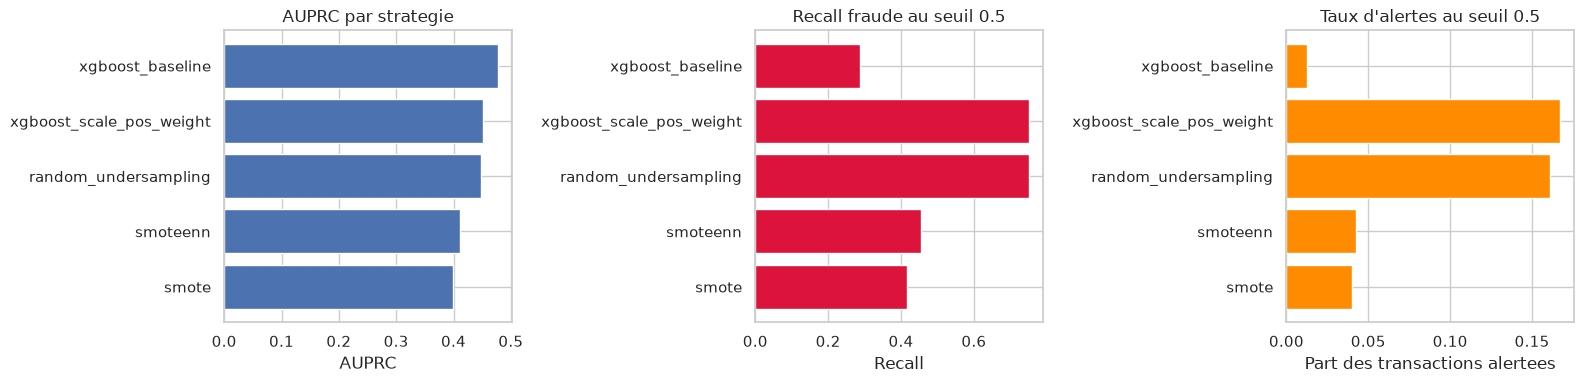

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_df = results_df.sort_values("AUPRC", ascending=True)

axes[0].barh(plot_df["strategy"], plot_df["AUPRC"])
axes[0].set_title("AUPRC par strategie")
axes[0].set_xlabel("AUPRC")

axes[1].barh(plot_df["strategy"], plot_df["recall@0.5"], color="crimson")
axes[1].set_title("Recall fraude au seuil 0.5")
axes[1].set_xlabel("Recall")

axes[2].barh(plot_df["strategy"], plot_df["predicted_positive_rate"], color="darkorange")
axes[2].set_title("Taux d'alertes au seuil 0.5")
axes[2].set_xlabel("Part des transactions alertees")

plt.tight_layout()
save_plot("02_model_strategy_comparison.png")
plt.show()


## 11. Courbes Precision-Recall

Ces courbes permettent de choisir un seuil adapte au contexte metier. Un seuil de 0.5 n'est pas forcement optimal en fraude.


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_precision_recall_curves.png


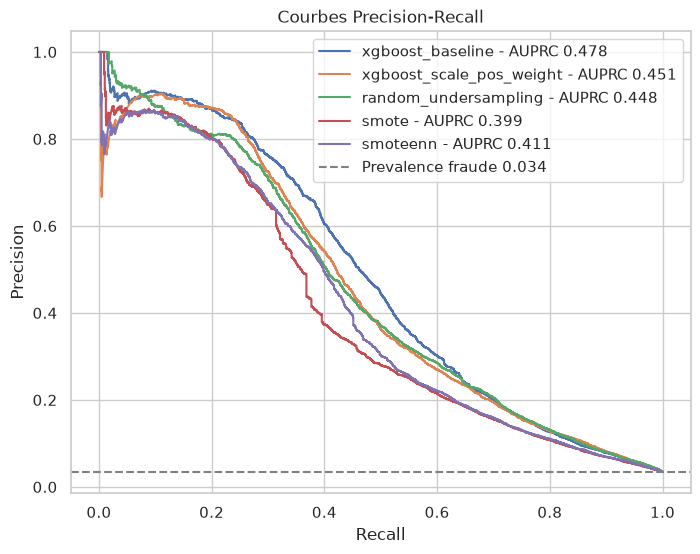

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for strategy, scores in scores_by_strategy.items():
    precision, recall, _ = precision_recall_curve(y_valid_np, scores)
    auprc = average_precision_score(y_valid_np, scores)
    ax.plot(recall, precision, label=f"{strategy} - AUPRC {auprc:.3f}")

ax.axhline(y_valid_np.mean(), color="gray", linestyle="--", label=f"Prevalence fraude {y_valid_np.mean():.3f}")
ax.set_title("Courbes Precision-Recall")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
save_plot("02_precision_recall_curves.png")
plt.show()


## 12. Matrice de confusion du meilleur modele

On affiche la matrice de confusion du modele avec la meilleure AUPRC. Pour une recommandation finale, il faudra probablement ajuster le seuil en fonction de la capacite des analystes et du cout des faux negatifs.


Meilleure strategie par AUPRC : xgboost_baseline
              precision    recall  f1-score   support

    legitime       0.98      1.00      0.99    114044
      fraude       0.77      0.29      0.42      4064

    accuracy                           0.97    118108
   macro avg       0.87      0.64      0.70    118108
weighted avg       0.97      0.97      0.97    118108

Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_confusion_matrix_xgboost_baseline.png


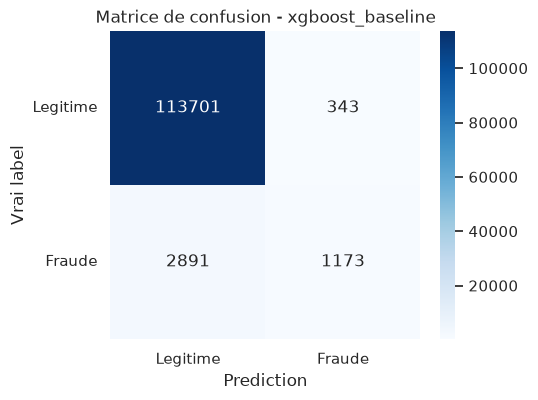

In [19]:
best_strategy = results_df.iloc[0]["strategy"]
best_scores = scores_by_strategy[best_strategy]
best_pred = (best_scores >= DECISION_THRESHOLD).astype(int)

print(f"Meilleure strategie par AUPRC : {best_strategy}")
print(classification_report(y_valid_np, best_pred, target_names=["legitime", "fraude"], zero_division=0))

cm = confusion_matrix(y_valid_np, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"Matrice de confusion - {best_strategy}")
ax.set_xlabel("Prediction")
ax.set_ylabel("Vrai label")
ax.set_xticklabels(["Legitime", "Fraude"])
ax.set_yticklabels(["Legitime", "Fraude"], rotation=0)
save_plot(f"02_confusion_matrix_{best_strategy}.png")
plt.show()


## 13. Ajustement du seuil metier

Le seuil 0.5 est arbitraire. En production, PayTrack doit choisir un seuil selon :
- le cout d'une fraude manquee ;
- le cout d'un faux positif ;
- la capacite quotidienne des analystes ;
- le niveau de friction acceptable pour les clients.

La cellule suivante compare plusieurs seuils pour le meilleur modele.


,threshold,precision,recall,F1,alert_rate,alerts_count
0,0.0500,0.1721,0.7333,0.2788,0.1466,17317
1,0.1000,0.3184,0.5832,0.4119,0.0630,7443
2,0.1500,0.4296,0.5084,0.4657,0.0407,4809
3,0.2000,0.5151,0.4537,0.4825,0.0303,3580
4,0.2500,0.5776,0.4158,0.4835,0.0248,2926
5,0.3000,0.6418,0.3875,0.4833,0.0208,2454
6,0.3500,0.6816,0.3588,0.4701,0.0181,2139
7,0.4000,0.7172,0.3332,0.4550,0.0160,1888
8,0.4500,0.7490,0.3127,0.4412,0.0144,1697
9,0.5000,0.7737,0.2886,0.4204,0.0128,1516


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/02_threshold_impact_xgboost_baseline.png


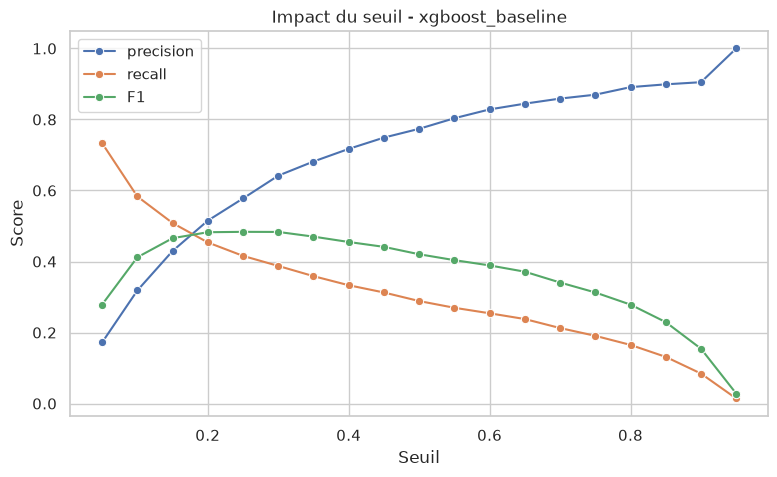

In [20]:
threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 19):
    preds = (best_scores >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_valid_np, preds, zero_division=0),
        "recall": recall_score(y_valid_np, preds, zero_division=0),
        "F1": f1_score(y_valid_np, preds, zero_division=0),
        "alert_rate": preds.mean(),
        "alerts_count": preds.sum(),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="threshold", y="precision", marker="o", label="precision", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="recall", marker="o", label="recall", ax=ax)
sns.lineplot(data=threshold_df, x="threshold", y="F1", marker="o", label="F1", ax=ax)
ax.set_title(f"Impact du seuil - {best_strategy}")
ax.set_xlabel("Seuil")
ax.set_ylabel("Score")
save_plot(f"02_threshold_impact_{best_strategy}.png")
plt.show()


## 14. Recommandation a rediger

A completer apres execution :

1. **Meilleure strategie par AUPRC** : `...`.
2. **Strategie avec meilleur recall** : `...`.
3. **Strategie la plus couteuse en alertes** : `...`.
4. **Strategie recommandee au CDO** : `...`.
5. **Justification metier** :
   - faux negatifs = fraudes manquees et chargebacks ;
   - faux positifs = clients legitimes bloques et charge analystes ;
   - un bon modele doit maximiser AUPRC/recall sans exploser le taux d'alertes.

Phrase type :

> Je recommande `...` car cette strategie obtient le meilleur compromis entre AUPRC, recall fraude et taux d'alertes. Le seuil de decision devra etre ajuste selon la capacite operationnelle des analystes, car le seuil 0.5 n'est pas automatiquement optimal en detection de fraude.


## 15. Prochaine etape

Apres ce notebook :

- ajouter des features graphe avec NetworkX sur un sous-ensemble client-marchand ;
- comparer XGBoost seul vs XGBoost + features graphe ;
- preparer le notebook MLOps avec MLflow, SHAP et Evidently.
